In [1]:
import sys
!{sys.executable} -m pip install emoji

In [2]:
import re
import nltk
from nltk.tokenize import word_tokenize
import emoji
import numpy as np

from utils2 import get_dict

nltk.download('punkt')  # download pre-trained Punkt tokenizer for English

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\hamza\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

# Data preparation 

## Cleaning and tokenization 

In [3]:
corpus = 'Who ❤️ "word embeddings" in 2020? I do!!!'

In [4]:
print (f'Corpus: {corpus} ')
data = re.sub(r'[,!?;-]+','.', corpus)
print (f'After cleaning punctuation: {data}') 

Corpus: Who ❤️ "word embeddings" in 2020? I do!!! 
After cleaning punctuation: Who ❤️ "word embeddings" in 2020. I do.


In [5]:
print(f'Initial string: {data}')
data = nltk.word_tokenize(data)
print('After tokenization: {data}')

Initial string: Who ❤️ "word embeddings" in 2020. I do.
After tokenization: {data}


In [6]:
print('Initial list of tokens: {data}')
data = [    ch.lower() for ch in data
            if ch.isalpha()
            or ch == '.'
            or emoji.is_emoji(ch) # keeps emojis.
        ]
print (f'After cleaning {data}')

Initial list of tokens: {data}
After cleaning ['who', '❤️', 'word', 'embeddings', 'in', '.', 'i', 'do', '.']


In [7]:
def tokenize (corpus):
    data = re.sub(r'[,!?;-]+','.', corpus)
    data = nltk.word_tokenize(data) # tokenize strings to words
    data = [    ch.lower() for ch in data
            if ch.isalpha()
            or ch == '.'
            or emoji.is_emoji(ch) # keeps emojis.
        ]
    return data


In [8]:
corpus = 'I am happy because I am learning'
print(f'Corpus:  {corpus}')
words = tokenize(corpus)
print(f'Words (tokens):  {words}')

Corpus:  I am happy because I am learning
Words (tokens):  ['i', 'am', 'happy', 'because', 'i', 'am', 'learning']


## Sliding window of words

In [9]:
def get_windows (words, C = 2):
    i = C
    while i < len (words) - C:
        center_word = words[i]
        context_word = words[i-C : i] + words[i+1 : i+C+1 ]
        yield context_word,center_word #using yield instead of return. return immediately exit the function, 
                                       #yield, pauses the function, sends back a value temporarily, and allows the function to continue later from the same point.
        i +=1

In [10]:
corpus = 'I am happy because I am learning'
words = tokenize(corpus)

print (tokenize(corpus))

['i', 'am', 'happy', 'because', 'i', 'am', 'learning']


## Transforming words into vectors 

### Mapping words to indices and indices to words

In [11]:
# Get word2Ind and Ind2word dicts for the tokenized corpus
word2Ind, In2word = get_dict (words)

In [12]:
word2Ind

{'am': 0, 'because': 1, 'happy': 2, 'i': 3, 'learning': 4}

In [13]:
print("Index of the word 'i':  ",word2Ind['i'])

Index of the word 'i':   3


In [14]:
# print value for the key '2' within In2word dictionary 
print("Word which has index 2: ",In2word[2])

Word which has index 2:  happy


In [ ]:
In2word

In [15]:
print("word which has index 2:",In2word[2] )

word which has index 2: happy


In [16]:
# Save length of word2Ind dict into the 'V' variable
V = len(word2Ind)

print("Size of vocabulary: ",V) 

Size of vocabulary:  5


### Getting one-hot word vectors


In [17]:
# Save index of word 'happy' into the 'n' Variable
n =word2Ind['happy']
n


2

In [18]:
center_word_vector = np.zeros(V) # vector filled with zeros with the same size as the vocabulary 
center_word_vector


array([0., 0., 0., 0., 0.])

In [19]:
len(center_word_vector) == V # Assert that vocab length and center_word_vector length is the same

True

In [20]:
# Replace element number 'n' with a 1
center_word_vector[n] = 1


In [21]:
center_word_vector

array([0., 0., 1., 0., 0.])

In [22]:
# all in 1 function
def word_to_one_hot_vector (word, word2Ind, V):
    one_hot_vector = np.zeros(V)
    one_hot_vector[word2Ind[word]] = 1
    return one_hot_vector

In [23]:
word_to_one_hot_vector('happy', word2Ind, V)

array([0., 0., 1., 0., 0.])

In [24]:
word_to_one_hot_vector('learning', word2Ind, V)

array([0., 0., 0., 0., 1.])

### Getting  context word vectors


In [26]:
context_words = ['i', 'am', 'because', 'i']

In [27]:
context_words_vectors = [word_to_one_hot_vector(w, word2Ind, V) for w in context_words]
context_words_vectors

[array([0., 0., 0., 1., 0.]),
 array([1., 0., 0., 0., 0.]),
 array([0., 1., 0., 0., 0.]),
 array([0., 0., 0., 1., 0.])]

In [28]:
np.mean(context_words_vectors, axis=0)

array([0.25, 0.25, 0.  , 0.5 , 0.  ])

In [ ]:
# All in one function
def context_words_to_vector (context_words, word2Ind, V):
    context_words_vectors = [word_to_one_hot_vector(w ,word2Ind,V) for w in context_words ] 
    context_words_vectors = np.mean(context_words_vectors, axis=0)
    return context_words_vectors

In [29]:
context_words_to_vector(['i', 'am', 'because', 'i'], word2Ind, V)

array([0.25, 0.25, 0.  , 0.5 , 0.  ])

In [30]:
context_words_to_vector(['am', 'happy', 'i', 'am'], word2Ind, V)

array([0.5 , 0.  , 0.25, 0.25, 0.  ])

## Building the training set

In [31]:
words

['i', 'am', 'happy', 'because', 'i', 'am', 'learning']

In [32]:
# Print vectors associated to center and context words for corpus
for context_words, center_word in get_windows(words, 2):
    print(f'Context words:  {context_words} -> {context_words_to_vector(context_words, word2Ind, V)}')
    print(f'Center word:  {center_word} -> {word_to_one_hot_vector(center_word, word2Ind, V)}')
    print()

Context words:  ['i', 'am', 'because', 'i'] -> [0.25 0.25 0.   0.5  0.  ]
Center word:  happy -> [0. 0. 1. 0. 0.]

Context words:  ['am', 'happy', 'i', 'am'] -> [0.5  0.   0.25 0.25 0.  ]
Center word:  because -> [0. 1. 0. 0. 0.]

Context words:  ['happy', 'because', 'am', 'learning'] -> [0.25 0.25 0.25 0.   0.25]
Center word:  i -> [0. 0. 0. 1. 0.]



In [33]:
# Define the generator function associated to center and context words for corpus using the generator function
def get_training_example (words, C, word2Ind, V):
    for context_words, center_word in  get_windows (words, C):
        yield context_words_to_vector(context_words, word2Ind, V), word_to_one_hot_vector(center_word, word2Ind, V)

In [34]:
# Print vectors associated to center and context words for corpus using the generator function
for context_words_vector, center_word_vector in get_training_example(words, 2, word2Ind, V):
    print(f'Context words vector:  {context_words_vector}')
    print(f'Center word vector:  {center_word_vector}')
    print()

Context words vector:  [0.25 0.25 0.   0.5  0.  ]
Center word vector:  [0. 0. 1. 0. 0.]

Context words vector:  [0.5  0.   0.25 0.25 0.  ]
Center word vector:  [0. 1. 0. 0. 0.]

Context words vector:  [0.25 0.25 0.25 0.   0.25]
Center word vector:  [0. 0. 0. 1. 0.]



# The continuous bag-of-words model 

The CBOW model is based on a neural network, the architecture of which looks like the figure below
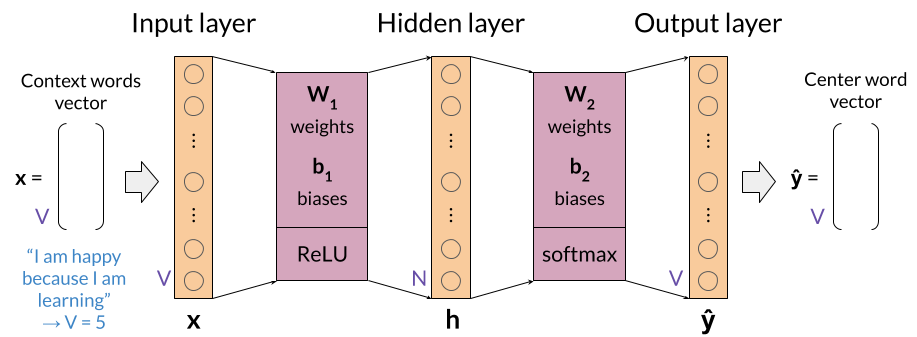
- The two activation functions used in the neural network.

- Forward propagation.

- Cross-entropy loss.

- Backpropagation.

- Gradient descent.

- Extracting the word embedding vectors from the weight matrices once the neural network has been trained.

## Activation functions

### ReLU

ReLU is used to calculate the values of the hidden layer, in the following formulas:

\begin{align}
 \mathbf{z_1} &= \mathbf{W_1}\mathbf{x} + \mathbf{b_1}  \tag{1} \\
 \mathbf{h} &= \mathrm{ReLU}(\mathbf{z_1})  \tag{2} \\
\end{align}


In [35]:
np.random.seed(10)
z_1 = 10*np.random.rand(5, 1)-5
z_1

array([[ 2.71320643],
       [-4.79248051],
       [ 1.33648235],
       [ 2.48803883],
       [-0.01492988]])

In [37]:
h = z_1.copy()
h[h<0] = 0 
h

array([[2.71320643],
       [0.        ],
       [1.33648235],
       [2.48803883],
       [0.        ]])

In [38]:
def relu (z):
    result = z.copy()
    result[result < 0] =  0
    return result


In [39]:
z = np.array([[-1.25459881], [ 4.50714306], [ 2.31993942], [ 0.98658484], [-3.4398136 ]])
relu(z)

array([[0.        ],
       [4.50714306],
       [2.31993942],
       [0.98658484],
       [0.        ]])

### Softmax

The second activation function that you need is softmax. This function is used to calculate the values of the output layer of the neural network, using the following formulas:

\begin{align}
 \mathbf{z_2} &= \mathbf{W_2}\mathbf{h} + \mathbf{b_2}   \tag{3} \\
 \mathbf{\hat y} &= \mathrm{softmax}(\mathbf{z_2})   \tag{4} \\
\end{align}

To calculate softmax of a vector $\mathbf{z}$, the $i$-th component of the resulting vector is given by:

$$ \textrm{softmax}(\textbf{z})_i = \frac{e^{z_i} }{\sum\limits_{j=1}^{V} e^{z_j} }  \tag{5} $$

In [40]:
z = np.array([9, 8, 11, 10, 8.5])

In [41]:
e_z = np.exp(z)
e_z


array([ 8103.08392758,  2980.95798704, 59874.1417152 , 22026.46579481,
        4914.7688403 ])

In [42]:
sum_e_z = np.sum(e_z)
e_z[0]/sum_e_z

np.float64(0.08276947985173956)

In [43]:
def softmax(z):
    e_z = np.exp(z)
    sum_e_z = np.sum(e_z)
    return e_z/sum_e_z

In [44]:
softmax([9, 8, 11, 10, 8.5])

array([0.08276948, 0.03044919, 0.61158833, 0.22499077, 0.05020223])

## Dimensions: 1-D arrays vs 2-D column vectors

In [45]:
V = 5 # Vocabulary size
x_array = np.zeros(V) # x_array is array of zeros with the same size as V
x_array

array([0., 0., 0., 0., 0.])

In [46]:
x_array.shape

(5,)

To perform matrix multiplication in the next steps, you actually need your column vectors to be represented as a matrix with one column. In numpy, this matrix is represented as a 2-dimensional array.

The easiest way to convert a 1D vector to a 2D column matrix is to set its .shape property to the number of rows and one column, as shown in the next cell.

In [47]:
x_column_vector = x_array.copy()
x_column_vector.shape = (V,1) # alternatively (x_array.shape[0], 1)
x_column_vector

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [48]:
x_column_vector.shape

(5, 1)